In [1]:
import pandas as pd

df = pd.read_csv("/content/Emotion_classify_Data.csv")

print(df.shape)

df.head()

(5937, 2)


,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [2]:
#che ck distribution of emotions
emt_dist = df['Emotion'].value_counts()
print(emt_dist)

Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


In [4]:
df['Emotion_num'] = df['Emotion'].map({
    'anger':0,
    'joy':1,
    'fear':2
})
df.head()

,Comment,Emotion,Emotion_num
0,i seriously hate one subject to death but now ...,fear,2
1,im so full of life i feel appalled,anger,0
2,i sit here to write i start to dig out my feel...,fear,2
3,ive been really angry with r and i feel like a...,joy,1
4,i feel suspicious if there is no one outside l...,fear,2


modeling without pre-processing text data

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['Comment'],
                                                    df['Emotion_num'],
                                                    test_size=0.2,
                                                    random_state=2022,
                                                    stratify=df['Emotion_num']
                                                    )
print("Shape of X_train :", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("\nNumber of training samples :", y_train.shape[0])
print("Number of testing samples :", y_test.shape[0])

Shape of X_train : (4749,)
Shape of X_test : (1188,)

Number of training samples : 4749
Number of testing samples : 1188


In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf_rf = Pipeline([
    ('vectorizer_count', CountVectorizer(ngram_range=(3,3))),
    ('random_forest', (RandomForestClassifier()))
])

clf_rf.fit(X_train, y_train)

y_pred = clf_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.44      0.46       400
           1       0.58      0.27      0.37       400
           2       0.42      0.70      0.53       388

    accuracy                           0.47      1188
   macro avg       0.50      0.47      0.45      1188
weighted avg       0.50      0.47      0.45      1188



In [13]:
clf_mnb = Pipeline([
    ('vectorizer_count', CountVectorizer(ngram_range=(1,2))),
    ('multinomial_nb', (MultinomialNB()))
])

clf_mnb.fit(X_train, y_train)

y_pred = clf_mnb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       400
           1       0.88      0.88      0.88       400
           2       0.86      0.86      0.86       388

    accuracy                           0.88      1188
   macro avg       0.88      0.88      0.88      1188
weighted avg       0.88      0.88      0.88      1188



In [14]:
clf_rf = Pipeline([
    ('vectorizer_count', CountVectorizer(ngram_range=(1,2))),
    ('random_forest', (RandomForestClassifier()))
])

clf_rf.fit(X_train, y_train)

y_pred = clf_rf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       400
           1       0.88      0.94      0.91       400
           2       0.93      0.88      0.91       388

    accuracy                           0.91      1188
   macro avg       0.91      0.91      0.91      1188
weighted avg       0.91      0.91      0.91      1188



In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

clf_rf = Pipeline([
    ('vectorizer_tfidf', TfidfVectorizer()),
    ('random_forest', (RandomForestClassifier()))
])
clf_rf.fit(X_train, y_train)

y_pred = clf_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       400
           1       0.91      0.94      0.92       400
           2       0.92      0.93      0.92       388

    accuracy                           0.92      1188
   macro avg       0.92      0.92      0.92      1188
weighted avg       0.92      0.92      0.92      1188



Use text pre-processing to remove stop words, punctuations and apply lemmatization

In [16]:
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm")

#use this utility function to get the preprocessed text data
def preprocess(text):

  #remove stpo words and lemmatize the text
  doc = nlp(text)
  filtered_tokens = []
  for token in doc:
    if token.is_stop or token.is_punct:
      continue
    filtered_tokens.append(token.lemma_)

  return " ".join(filtered_tokens)

In [17]:
# create a new column "preprocessed_comment" and use the utility function above to get the clean data
df['Preprocessed_Comment'] = df['Comment'].apply(preprocess)
df.head()

,Comment,Emotion,Emotion_num,Preprocessed_Comment
0,i seriously hate one subject to death but now ...,fear,2,seriously hate subject death feel reluctant drop
1,im so full of life i feel appalled,anger,0,m life feel appalled
2,i sit here to write i start to dig out my feel...,fear,2,sit write start dig feeling think afraid accep...
3,ive been really angry with r and i feel like a...,joy,1,ve angry r feel like idiot trust place
4,i feel suspicious if there is no one outside l...,fear,2,feel suspicious outside like rapture happen


build a model with pre-processed text

In [18]:
X_train, X_test, y_train, y_test = train_test_split(df['Preprocessed_Comment'],
                                                    df['Emotion_num'],
                                                    test_size=0.2,
                                                    random_state=2022,
                                                    stratify=df['Emotion_num']
                                                    )
print("Shape of X_train :", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("\nNumber of training samples :", y_train.shape[0])
print("Number of testing samples :", y_test.shape[0])

Shape of X_train : (4749,)
Shape of X_test : (1188,)

Number of training samples : 4749
Number of testing samples : 1188


In [19]:
clf_rf = Pipeline([
    ("countvectorizer", CountVectorizer(ngram_range=(1,2))),
    ('random_forest', (RandomForestClassifier()))
])

clf_rf.fit(X_train, y_train)

y_pred = clf_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       400
           1       0.93      0.94      0.94       400
           2       0.93      0.91      0.92       388

    accuracy                           0.93      1188
   macro avg       0.93      0.93      0.93      1188
weighted avg       0.93      0.93      0.93      1188



In [21]:
clf_rf = Pipeline([
    ('vectorizer_tfidf', TfidfVectorizer()),
    ('random_forest', (RandomForestClassifier()))
])

clf_rf.fit(X_train, y_train)

y_pred = clf_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       400
           1       0.95      0.95      0.95       400
           2       0.92      0.93      0.92       388

    accuracy                           0.93      1188
   macro avg       0.93      0.93      0.93      1188
weighted avg       0.93      0.93      0.93      1188



In [22]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[368  15  17]
 [  6 379  15]
 [ 22   7 359]]


Text(50.722222222222214, 0.5, 'Truth')

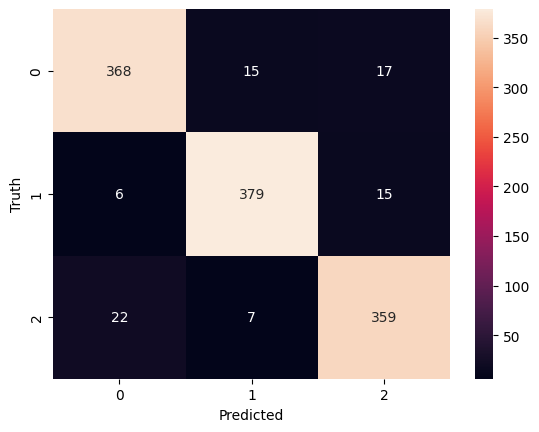

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Truth")